## Walmart Sales EDA
Olá! Seja bem-vindo(a)!

Este projeto foi desenvolvido com foco no desenvolvimento do meu portfólio de análise de dados, demonstrando minhas habilidades em Limpeza e Análise Exploratória de Dados com Python.

### Contexto
O dataset utilizado é o "Walmart Dataset", disponível no Kaggle (https://www.kaggle.com/datasets/yasserh/walmart-dataset).
Ele contém dados históricos de vendas semanais de 45 lojas do Walmart entre 02/2010 e 11/2012.

### Perguntas de Negócio
Esta análise exploratória busca responder 3 perguntas de negócio, sobre o comportamento de vendas do Walmart:

1. Quais lojas apresentam o maior e menor volume de vendas semanais? <br>
   **Objetivo**: Identificar lojas de alto e baixo desempenho para replicar boas práticas ou investigar gargalos operacionais.

2. Lojas com vendas mais baixas estão concentradas em regiões com CPI mais alto? <br>
   **Objetivo**: Verificar se o custo de vida da região explica a baixa performance de certas lojas, ajudando o negócio a diferenciar problemas operacionais de problemas estruturais do mercado local.

3. Semanas com feriados realmente geram vendas maiores do que semanas normais? <br>
   **Objetivo**: Justificar ou redirecionar investimentos em estoque e equipe conforme o real impacto dos feriados nas vendas.


### Etapas da Análise

- Importação de bibliotecas e carregamento dos dados
- Limpeza, tratamento e preparação
- Análise Exploratória de Dados (EDA) 
- Conclusões

---

Fique à vontade para entrar em contato comigo. Boa leitura!

### Importação das bibliotecas

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import seaborn as sns


c:\Users\diogo\anaconda3\envs\env-novoprojeto\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Importação de dados
Importação direto da fonte de dados Kaggle, via código.

In [2]:
path = kagglehub.dataset_download("yasserh/walmart-dataset")

In [3]:
df = pd.read_csv(path + '\\Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


### 🧹Limpeza, tratamento e exploração
    1. Ajuste tipo da coluna Store de int64 para str, afinal não serão utilizados cálculos.
    2. Ajuste tipo da coluna Date de int64 para data.
    3. Não identificadas linhas vazias para tratamento.
    4. Não identificadas linhas duplicadas para tratamento.

In [ ]:
#1
df['Store'] = df['Store'].astype(str)
#2
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   object        
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 402.3+ KB


In [ ]:
#3
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
#4
df.duplicated().sum()

np.int64(0)

### 📊 Análise exploratória de dados (EDA)
    
    1. Quais lojas apresentam o maior e menor volume de vendas semanais?

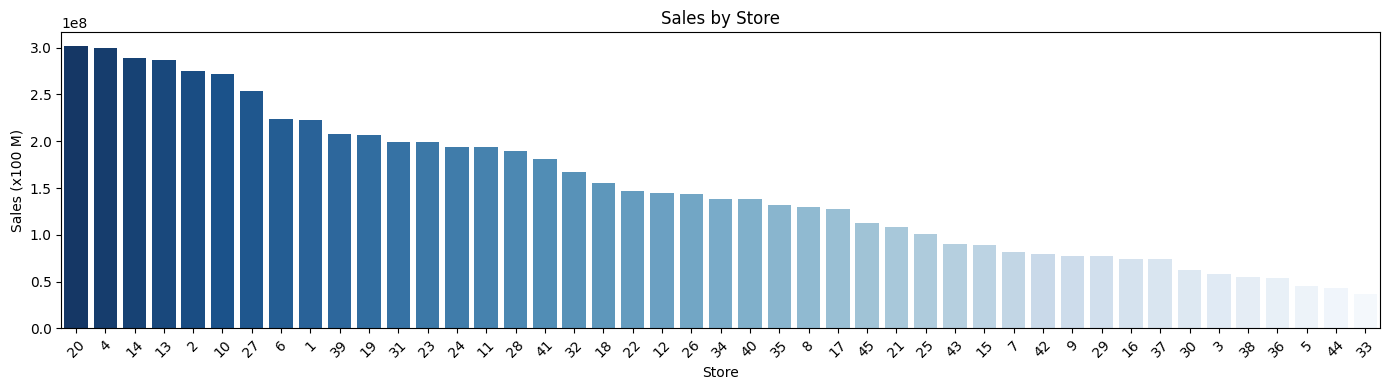

In [7]:
df_store = df.groupby('Store')['Weekly_Sales'].sum().reset_index()
df_store = df_store.sort_values('Weekly_Sales', ascending=False)

plt.figure(figsize=(14, 4))
sns.barplot(
    data=df_store,
    x='Store',
    y='Weekly_Sales',
    palette='Blues_r',
    order=df_store['Store'],
    hue='Store',

)

plt.title('Sales by Store')
plt.xlabel('Store')
plt.ylabel('Sales (x100 M)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Utilizando o Coeficiente de Variação (CV) (Desvio padrão dividido pela média), busca-se identificar se as lojas com maior faturamento possuem uma grande dispersão nos dados, o que poderia indicar que o alto faturamento é resultado de vendas esporádicas, e não de um histórico consistente de vendas e atração de clientes.

- CV < 15% → baixa variabilidade, vendas consistentes
- CV entre 15% e 30% → variabilidade moderada
- CV > 30% → alta variabilidade, vendas instáveis

In [ ]:
lojas_venda_alta = df[df['Store'].isin(['2','4','10','13','14','20','27'])]

cv_vendas_alta = lojas_venda_alta.groupby('Store')['Weekly_Sales'].std() / lojas_venda_alta.groupby('Store')['Weekly_Sales'].mean()*100
cv_vendas_alta

Store
10    15.913349
13    13.251363
14    15.713674
2     12.342388
20    13.090269
27    13.515544
4     12.708254
Name: Weekly_Sales, dtype: float64

A suspeita de que o CV seria elevado entre as lojas com maiores vendas se mostra infundada, uma vez que a variância oscila entre 12% e 15% — valor alto, mas similar ao das demais lojas, caracterizando um comportamento dentro do esperado.

Dessa forma, essas lojas demonstram que suas maiores vendas não dependem de picos incomuns de demanda, mas sim de algum fator consistente que as diferencia no mercado.

In [9]:
cv_geral = df.groupby('Store')['Weekly_Sales'].std() / df.groupby('Store')['Weekly_Sales'].mean()*100
cv_geral

Store
1     10.029212
10    15.913349
11    12.226183
12    13.792532
13    13.251363
14    15.713674
15    19.338399
16    16.518065
17    12.552067
18    16.284550
19    13.268012
2     12.342388
20    13.090269
21    17.029239
22    15.678288
23    17.972115
24    12.363738
25    15.986040
26    11.011066
27    13.515544
28    13.732974
29    18.374247
3     11.502141
30     5.200804
31     9.016105
32    11.831049
33     9.286835
34    10.822524
35    22.968111
36    16.257891
37     4.208412
38    11.087545
39    14.990779
4     12.708254
40    12.342978
41    14.817711
42     9.033533
43     6.410363
44     8.179331
45    16.561273
5     11.866844
6     13.582286
7     19.730469
8     11.695283
9     12.689547
Name: Weekly_Sales, dtype: float64

### 📊 Análise exploratória de dados (EDA)
    
    2. Lojas com vendas mais baixas estão concentradas em regiões com CPI mais alto?

In [39]:
df_agrupado = df.groupby('Store')['Weekly_Sales'].sum().astype(int).sort_values(ascending=True)
df_agrupado.head(8)

Store
33    37160221
44    43293087
5     45475688
36    53412214
38    55159626
3     57586735
30    62716885
37    74202740
Name: Weekly_Sales, dtype: int64

In [40]:
cpi_lojas = df.groupby('Store')['CPI'].mean().reset_index().sort_values('CPI',ascending=True)
cpi_lojas['cpi_quartile'] = pd.qcut(cpi_lojas['CPI'], q=4, labels=['Q1','Q2','Q3','Q4'])

cpi_lojas_agrupado = cpi_lojas.groupby('cpi_quartile')['CPI'].agg(
    CPI_min = 'min',
    CPI_max = 'max'
).astype(int).reset_index()
cpi_lojas_agrupado

C:\Users\diogo\AppData\Local\Temp\ipykernel_27460\2674859231.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cpi_lojas_agrupado = cpi_lojas.groupby('cpi_quartile')['CPI'].agg(


,cpi_quartile,CPI_min,CPI_max
0,Q1,128,135
1,Q2,139,186
2,Q3,193,214
3,Q4,215,219


Após identificar as lojas com menores vendas, analisei a distribuição de quartis geral e comparei com a média do CPI (IPCA americano) entre as lojas de baixo desempenho e as demais, concluindo que não existe uma correlação direta entre a inflação da região e o baixo volume de vendas.
<br>
O CPI médio das lojas com vendas baixas é 169, enquanto nas demais é 183 — ambos dentro do mesmo quartil (Q2), representando uma variação pequena. Isso reforça que a inflação regional não é um fator explicativo para o desempenho inferior dessas lojas.

In [41]:
lojas_venda_baixa = df['Store'].astype(str).isin(['33','44','5','36','38','3','30','37'])

df['grupo_venda_baixa'] = lojas_venda_baixa.map({True:'Venda Baixa', False:'Demais'})
comparacao = df.groupby('grupo_venda_baixa')['CPI'].mean()
print(comparacao)

grupo_venda_baixa
Demais         169.025058
Venda Baixa    183.387571
Name: CPI, dtype: float64


### 📊 Análise exploratória de dados (EDA)
    
    3. Semanas com feriados realmente geram vendas maiores do que semanas normais?

In [13]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean().reset_index().astype(int)

,Holiday_Flag,Weekly_Sales
0,0,1041256
1,1,1122887


In [14]:
medias = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
((medias[1] / medias[0] -1) *100)

np.float64(7.839713033050177)

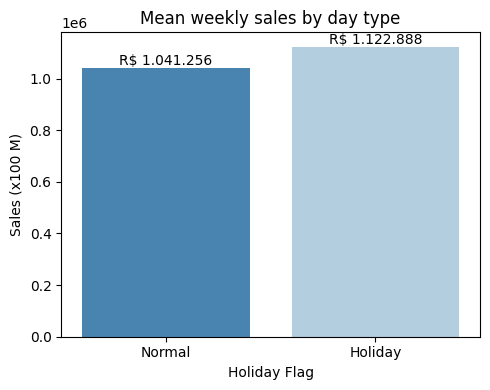

In [15]:
df_holiday = df.groupby('Holiday_Flag')['Weekly_Sales'].mean().reset_index()
df_holiday = df_holiday.sort_values('Weekly_Sales', ascending=True)

plt.figure(figsize=(5, 4))
ax = sns.barplot(
    data=df_holiday,
    x='Holiday_Flag',
    y='Weekly_Sales',
    palette='Blues_r',
    #order=df_holiday['Store'],
    hue='Holiday_Flag',
    )
for container in ax.containers:
     ax.bar_label(container, fmt=lambda x: f'R$ {x:,.0f}'.replace(',', '.'))
plt.legend().remove()
plt.title('Mean weekly sales by day type')
plt.xlabel('Holiday Flag')
plt.ylabel('Sales (x100 M)')
plt.xticks([0, 1], ['Normal', 'Holiday'])
plt.tight_layout()
plt.show()

In [ ]:
df_holiday_store = df.groupby(['Store','Holiday_Flag'])['Weekly_Sales'].mean().unstack()
df_holiday_store['Var'] = (((df_holiday_store[1]/df_holiday_store[0])-1)*100).round()
df_holiday_store = df_holiday_store.sort_values(by='Var',ascending=False)
df_holiday_store

Holiday_Flag,0,1,Var
Store,,,
7,5.629645e+05,672400.265,19.0
35,9.080992e+05,1074348.457,18.0
5,3.148923e+05,359501.607,14.0
15,6.170648e+05,706406.018,14.0
12,9.992919e+05,1138140.420,14.0
29,5.343758e+05,606957.889,14.0
28,1.311889e+06,1478244.605,13.0
10,1.883309e+06,2113755.949,12.0
21,7.507742e+05,826491.309,10.0


Iniciando com uma análise geral, comparando a média de vendas em semanas com e sem feriados, identificamos uma variação positiva de 7%. Ao aprofundar a granularidade para o nível de loja, percebemos que essa variação é bastante heterogênea, com algumas lojas atingindo até 19% de aumento em semanas de feriado.

Dessa forma, confirma-se que semanas com feriados geram mais vendas, metade das lojas supera a variação média de 7%, enquanto a outra metade fica abaixo. Isso sugere que existe um potencial represado nas lojas que não conseguem tracionar as vendas nos feriados, sendo estas as principais candidatas a ações operacionais e comerciais direcionadas.

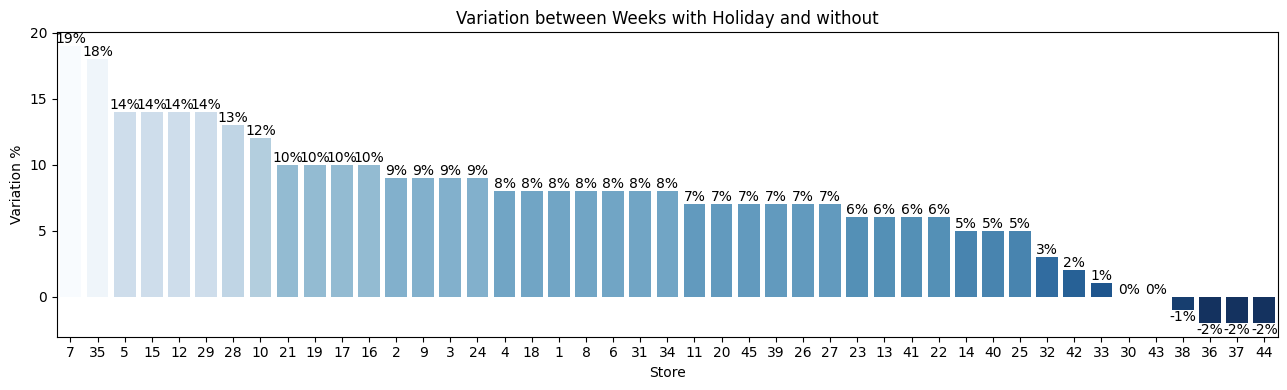

In [ ]:
plt.figure(figsize=(13, 4))
ax = sns.barplot(
    data=df_holiday_store,
    x='Store',
    y='Var',
    palette='Blues_r',
    hue='Var',
    )
for container in ax.containers:
     ax.bar_label(container, fmt=lambda x: f'{x:,.0f}%'.replace(',', '.'))
plt.legend().remove()
plt.title('Variation between Weeks with Holiday and without')
plt.xlabel('Store')
plt.ylabel('Variation %')
plt.tight_layout()
plt.show()

### 💡 Conclusão
Realizei neste estudo, uma análise exploratória, para identificação de padrões e informações que auxiliem o negócio a tomar decisões corretas, em prol ao aumento de receita e melhoria nas vendas.
Abaixo seguem respostas as perguntas propostas inicialmente, juntamente com orientações para as melhores tomadas de decisão, ressalto que existiu uma limitação da quantidade de dados da fonte, portanto diversas análise posteriores, ficarão como apenas recomendação:
<hr>

### 1. Quais lojas apresentam o maior e menor volume de vendas semanais? <br>
As lojas com as maiores vendas são ['2','4','10','13','14','20','27']. 
Houve uma suspeita sobre a uniformidade das vendas destas lojas, ou seja, se elas estão entre as que mais vendem, por causa de momentos de vendas esporádicas, contudo, utilizando-me do coeficiênte de variação e comparando o resultado com as demais lojas, entendemos que realmente, estas possuem o padrão de vendas maiores ao longo do tempo.

**Orientações e Insights**: Oriento que seja realizado uma análise mais detalhada, respondendo a pergunta: "Estas lojas vendem mais por alguma razão intrinseca (Gestão), ou por fatores favoráveis externos?" como localização privilegiada, ou pouca concorrência, etc... 
Caso seja por razão intrinseca, será importante analisar cada detalhe da gestão dessas lojas e comparar com as demais, para aplicar as melhores práticas.
<hr>

### 2. Lojas com vendas mais baixas estão concentradas em regiões com CPI mais alto? <br>
Existe uma correlação pequena entre os dois fatores, mas ao ponto de não podermos admitir que está é uma correlação direta nos resultados das lojas.
   
**Orientações e Insights**: Oriento que seja feita uma análise exploratória e de correlação, descendo a granularidade, além de comparar apenas as lojas como foi feito, realizar a nível de produto ou segmento. Encontrando alguma correlação maior, que apenas vendas da loja como um todo, realizar um teste A/B nos produtos identificados como sensíveis, com foco em avaliar a elasticidade de preço dos consumidores da região.

<hr>

### 3. Semanas com feriados realmente geram vendas maiores do que semanas normais? <br>
Sim, existe um impacto positivo dos feriados nas vendas. Contudo, esse efeito é heterogêneo entre as lojas: metade delas aproveita o período com aumentos que variam de 7% a 19%, enquanto a outra metade apresenta crescimento abaixo de 7% — com alguns casos de queda em relação a semanas normais.

**Orientações e Insights**: Recomenda-se uma análise em menor granularidade, investigando as práticas comerciais e operacionais das lojas que mais se destacam em feriados, com o objetivo de identificar padrões replicáveis para as demais. Como ações promocionais, gestão de estoque e campanhas direcionadas para os feriados.